In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
import string
from collections import Counter

/kaggle/input/learn-ai-bbc/BBC News Train.csv
/kaggle/input/learn-ai-bbc/BBC News Sample Solution.csv
/kaggle/input/learn-ai-bbc/BBC News Test.csv


In [2]:
url_train = 'https://github.com/dnmorgan/MSDS/blob/DTSA5510/BBC_News_Train.csv?raw=true'
url_test = 'https://github.com/dnmorgan/MSDS/blob/DTSA5510/BBC_News_Test.csv?raw=true'
train_df = pd.read_csv(url_train,index_col=0)
test_df = pd.read_csv(url_test,index_col=0)

## Begin EDA

In [3]:
# Initial inspection
print("First few rows:")
print(train_df.head(), "\n")
print("Data info:")
print(train_df.info(), "\n")
print("Category distribution:")
print(train_df['Category'].value_counts(), "\n")

First few rows:
                                                        Text  Category
ArticleId                                                             
1833       worldcom ex-boss launches defence lawyers defe...  business
154        german business confidence slides german busin...  business
1101       bbc poll indicates economic gloom citizens in ...  business
1976       lifestyle  governs mobile choice  faster  bett...      tech
917        enron bosses in $168m payout eighteen former e...  business 

Data info:
<class 'pandas.core.frame.DataFrame'>
Index: 1490 entries, 1833 to 538
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Text      1490 non-null   object
 1   Category  1490 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB
None 

Category distribution:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64 



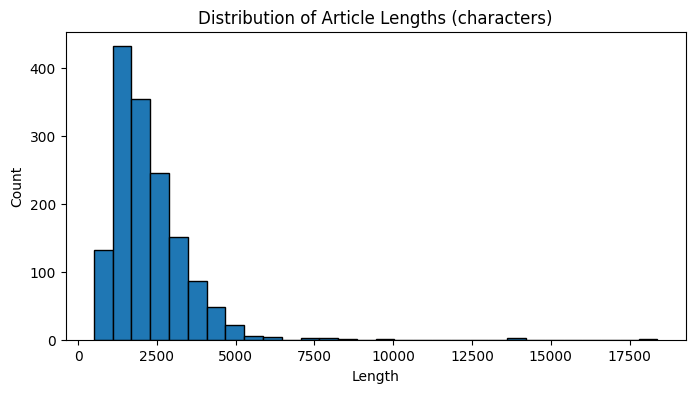

In [4]:
# Look at article length distribution
train_df['text_length'] = train_df['Text'].apply(len)
plt.figure(figsize=(8, 4))
plt.hist(train_df['text_length'], bins=30, edgecolor='black')
plt.title('Distribution of Article Lengths (characters)')
plt.xlabel('Length')
plt.ylabel('Count')
plt.show()

  * Article lengths (in characters) range broadly, with most articles between \~1,000–5,000 chars but a long tail of longer pieces.
   * This suggests we may need to standardize or truncate text lengths when modeling, or at least account for varying document sizes.


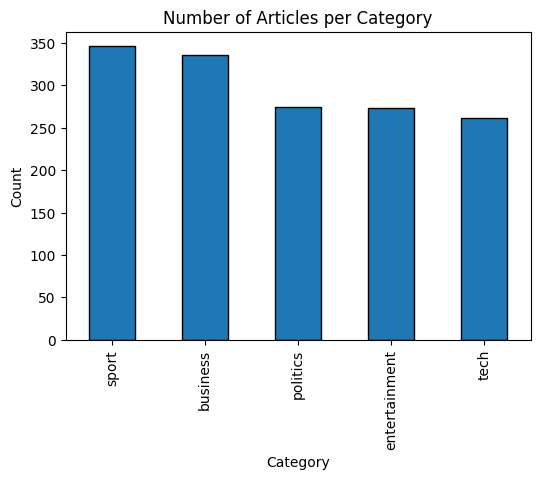

In [5]:
# Look at category distribution bar chart
plt.figure(figsize=(6, 4))
train_df['Category'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Number of Articles per Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()


In [6]:
# Double check if missing values and duplicates
print("Missing values by column:")
print(train_df.isnull().sum(), "\n")
print("Number of duplicate rows:", train_df.duplicated().sum(), "\n")

Missing values by column:
Text           0
Category       0
text_length    0
dtype: int64 

Number of duplicate rows: 50 



 * The dataset contains 1,490 articles with three columns: `ArticleId`, `Text`, and `Category`.
* No missing values were detected, and there were no exact duplicate rows.
* Articles are unevenly distributed among the five categories, but all are represented.

### Cleaning

In [7]:
# cleaning: lowercase, remove punctuation & numbers
def clean_text(series):
    return (series.str.lower()
                 .str.replace(f'[{string.punctuation}]', ' ', regex=True)
                 .str.replace(r'\d+', ' ', regex=True))

train_df['cleaned'] = clean_text(train_df['Text'])
test_df['cleaned']  = clean_text(test_df['Text'])


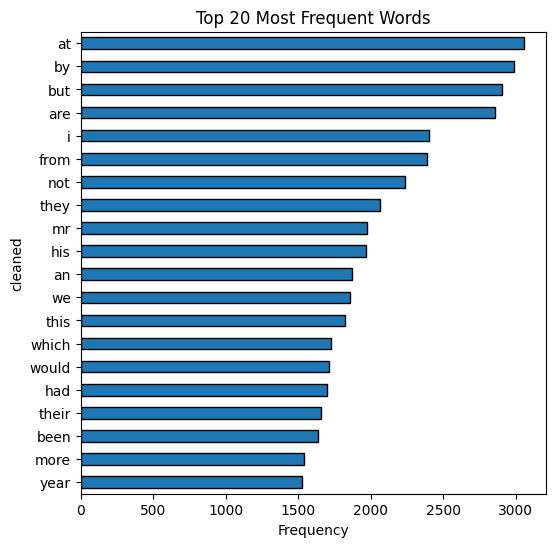

In [8]:
# Top 20 frequent words
# excluding common words
exclude_words = {
    'said', 'people', 'will', 'new', 'one', 'also', 'the','to','of','and','a','s','in','for','is','that','it','on','was','he','be','with','has','as','have'
}

# Explode all tokens
all_tokens = train_df['cleaned'].str.split().explode()

# Filter out your exclude list
filtered_tokens = all_tokens[~all_tokens.isin(exclude_words)]

# Recompute top 20
top20 = filtered_tokens.value_counts().head(20)

# Plot
plt.figure(figsize=(6, 6))
top20.sort_values().plot(
    kind='barh',
    edgecolor='black'
)
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.show()



   * Converted all text to lowercase.
   * Removed punctuation and numeric characters to focus on words.
   * Stored the cleaned text in a new column for downstream processing.


## Process the raw texts to word embedding.

In [9]:
# TF-IDF embedding
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X_train = vectorizer.fit_transform(train_df['cleaned'])
X_test  = vectorizer.transform(test_df['cleaned'])
y_train = train_df['Category']
print("TF-IDF matrix shape:", X_train.shape, "\n")

TF-IDF matrix shape: (1490, 5000) 



In [10]:
# Top TF-IDF words for the first document
feature_names = vectorizer.get_feature_names_out()
first_doc = X_train[0].toarray().ravel()
topn_ids = np.argsort(first_doc)[-10:][::-1]
topn_words = [(feature_names[i], first_doc[i]) for i in topn_ids]
print("Top TF-IDF words for the first document:")
for word, score in topn_words:
    print(f"{word}: {score:.4f}")

Top TF-IDF words for the first document:
worldcom: 0.5204
accounting: 0.3677
ebbers: 0.3628
cooper: 0.2345
fraud: 0.1813
lawyers: 0.1549
mr: 0.1431
charges: 0.1278
auditors: 0.1231
ms: 0.1213


**TF–IDF Embedding Summary**

* Used `sklearn`’s `TfidfVectorizer` (max\_features=5,000, English stopwords) to transform each cleaned article into a TF–IDF vector.
* The resulting matrix shape is (1490, 5000), i.e. one 5,000-dimensional feature vector per article.
* TF–IDF down-weights very common terms (across the corpus) and up-weights terms that are frequent in a given document but rare globally, helping highlight discriminative words.

## Unsupervised analysis with matrix factorization

In [11]:
#import more libraries for unsupervised analysis
from sklearn.decomposition import NMF
from sklearn.metrics import accuracy_score, confusion_matrix
from collections import Counter
import string

NMF (n_topics=5) -> train_acc: 0.9215
               business  entertainment  politics  sport  tech
business            312              1        13      0    10
entertainment         3            224         6      3    37
politics             21              0       244      2     7
sport                 1              2         0    343     0
tech                  2              4         1      4   250
NMF (n_topics=10) -> train_acc: 0.9282
               business  entertainment  politics  sport  tech
business            291              2        23      8    12
entertainment         4            255         7      2     5
politics              3              0       258      7     6
sport                 0              0         0    346     0
tech                  3              8         9      8   233
NMF (n_topics=15) -> train_acc: 0.9228
               business  entertainment  politics  sport  tech
business            294              1        14      8    19
entertainment   

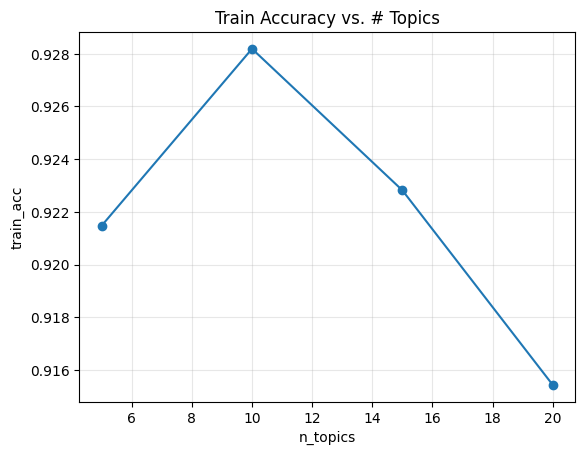

In [13]:
results = []
def run_nmf_experiment(n_topics):
    nmf = NMF(n_components=n_topics, random_state=0)
    W_train = nmf.fit_transform(X_train)
    W_test  = nmf.transform(X_test)
    
    # assign docs to their highest-weight topic
    train_topics = np.argmax(W_train, axis=1)
    test_topics  = np.argmax(W_test,  axis=1)
    
    # map topic -> majority train category
    mapping = {}
    for topic in range(n_topics):
        cats = train_df['Category'][train_topics == topic]
        mapping[topic] = cats.value_counts().idxmax() if not cats.empty else train_df['Category'].mode()[0]
    
    # train predictions & metrics
    y_train_pred = [mapping[t] for t in train_topics]
    train_acc     = accuracy_score(y_train, y_train_pred)
    cm_train      = confusion_matrix(y_train, y_train_pred, labels=sorted(train_df['Category'].unique()))

    # store results and append test predictions
    results.append({'n_topics': n_topics, 'train_acc': train_acc})
    test_df[f'predicted_nmf_{n_topics}'] = [mapping[t] for t in test_topics]

    print(f"NMF (n_topics={n_topics}) -> train_acc: {train_acc:.4f}")
    print(pd.DataFrame(
        cm_train,
        index=sorted(train_df['Category'].unique()),
        columns=sorted(train_df['Category'].unique())
    ))

# 5) Run and summarize
for k in [5, 10, 15, 20]:
    run_nmf_experiment(k)

results_df = pd.DataFrame(results)


plt.plot(results_df['n_topics'], results_df['train_acc'], marker='o')
plt.title('Train Accuracy vs. # Topics')
plt.xlabel('n_topics')
plt.ylabel('train_acc')
plt.grid(alpha=0.3)
plt.show()


## Changing hyperparameters and rerunning

NMF (n_topics=5) -> train_acc: 0.9141
               business  entertainment  politics  sport  tech
business            309              1        14      1    11
entertainment         5            215         7      4    42
politics             15              0       249      1     9
sport                 3              2         1    340     0
tech                  2              4         1      5   249
NMF (n_topics=10) -> train_acc: 0.9309
               business  entertainment  politics  sport  tech
business            304              1        13      6    12
entertainment         8            250         6      4     5
politics             10              0       245      9    10
sport                 0              1         0    345     0
tech                  3              7         2      6   243
NMF (n_topics=15) -> train_acc: 0.9114
               business  entertainment  politics  sport  tech
business            275              1        34     10    16
entertainment   

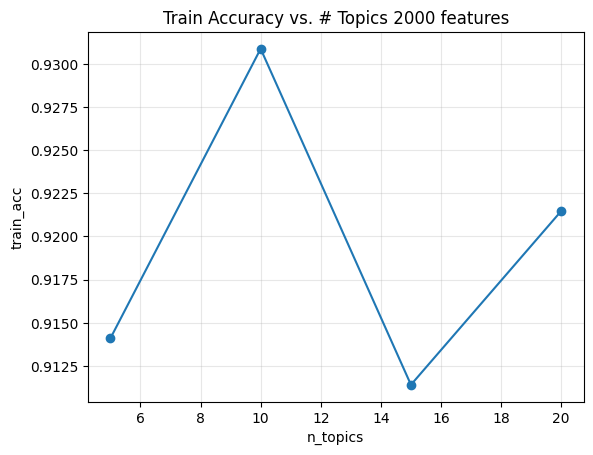

In [14]:
train_df['cleaned'] = clean_text(train_df['Text'])
test_df['cleaned']  = clean_text(test_df['Text'])

# 3) TF–IDF on train only
# change hyperparameter to 2000 instead of 5000
vectorizer = TfidfVectorizer(max_features=2000, stop_words='english')
X_train = vectorizer.fit_transform(train_df['cleaned'])
X_test  = vectorizer.transform(test_df['cleaned'])
y_train = train_df['Category']

results = []
# 5) Run and summarize
for k in [5, 10, 15, 20]:
    run_nmf_experiment(k)

results_df = pd.DataFrame(results)

plt.plot(results_df['n_topics'], results_df['train_acc'], marker='o')
plt.title('Train Accuracy vs. # Topics 2000 features')
plt.xlabel('n_topics')
plt.ylabel('train_acc')
plt.grid(alpha=0.3)
plt.show()


### N=2000 vs N=5000 takeaways:
* Both vocab sizes peak at *n*=10, but shrinking to 2,000 features nudged train accuracy up slightly (0.9309 vs. 0.9282).
* With only 5 or 15 topics, the smaller vocabulary lost a bit of fidelity (drops of \~0.007 and \~0.011 in accuracy).
* At 20 topics, the reduced feature set actually gained (\~+0.006), suggesting that some noise was pruned away.
* Lowering the vocab sometimes shifts which categories get confused. For example, at 20 topics you see more “politics” correctly captured in the 2,000‑feature run, but a few more business articles slip through.
* Sport remains very clean in both setups, while entertainment and tech misclassifications hover in similar ranges.
* A 2,000‑term TF–IDF basis with *n\_topics*≈10 gives the best of both worlds—slightly higher train accuracy and a leaner model. 

## Compare with supervised learning

           classifier  train_frac  train_acc   val_acc
0       MultinomialNB         0.1   1.000000  0.889262
1  LogisticRegression         0.1   1.000000  0.885906
2       MultinomialNB         0.2   1.000000  0.906040
3  LogisticRegression         0.2   1.000000  0.912752
4       MultinomialNB         0.5   0.996644  0.939597
5  LogisticRegression         0.5   1.000000  0.929530
6       MultinomialNB         1.0   0.988255  0.946309
7  LogisticRegression         1.0   0.994966  0.956376


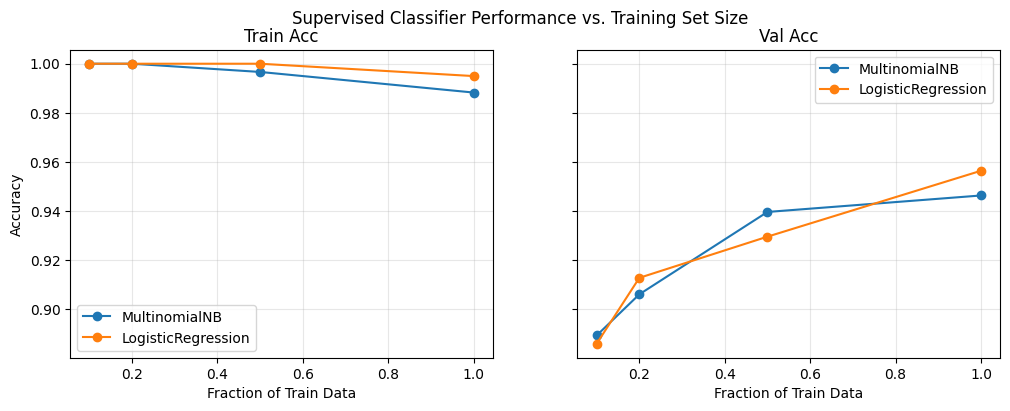

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1) Load & clean
df = pd.read_csv(url_train,index_col=0)
#print(df.columns)
def clean_text(s):
    return (s.str.lower()
             .str.replace(f'[{string.punctuation}]', ' ', regex=True)
             .str.replace(r'\d+', ' ', regex=True))

df['cleaned'] = clean_text(df['Text'])

#print(df.columns)

# 2) Train/validation split (80/20)
train_base, val = train_test_split(
    df, test_size=0.2, 
    stratify=df['Category'], 
    random_state=0
)

# 3) TF–IDF vectorizer fit on train_base only
vectorizer = TfidfVectorizer(max_features=2000, stop_words='english')
X_base = vectorizer.fit_transform(train_base['cleaned'])
y_base = train_base['Category']

X_val  = vectorizer.transform(val['cleaned'])
y_val  = val['Category']

# 4) Classifiers to compare
classifiers = {
    'MultinomialNB': MultinomialNB(),
    'LogisticRegression': LogisticRegression(max_iter=1000)
}

# 5) Loop over train-size fractions
fractions = [0.1, 0.2, 0.5, 1.0]
results = []

for frac in fractions:
    if frac < 1.0:
        # subsample a fraction of the base train
        X_sub, _, y_sub, _ = train_test_split(
            X_base, y_base,
            train_size=frac,
            stratify=y_base,
            random_state=0
        )
    else:
        # use the entire base train
        X_sub, y_sub = X_base, y_base

    for name, clf in classifiers.items():
        # train & evaluate
        clf.fit(X_sub, y_sub)
        train_acc = accuracy_score(y_sub, clf.predict(X_sub))
        val_acc   = accuracy_score(y_val, clf.predict(X_val))

        results.append({
            'classifier': name,
            'train_frac': frac,
            'train_acc': train_acc,
            'val_acc': val_acc
        })
results_df = pd.DataFrame(results)
print(results_df)

# Pivot for easier plotting
pivot = results_df.pivot(
    index='train_frac', 
    columns='classifier', 
    values=['train_acc','val_acc']
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i, metric in enumerate(['train_acc','val_acc']):
    ax = axes[i]
    for clf_name in classifiers:
        ax.plot(
            fractions,
            pivot[(metric, clf_name)],
            marker='o',
            label=clf_name
        )
    ax.set_title(metric.replace('_',' ').title())
    ax.set_xlabel('Fraction of Train Data')
    if i == 0:
        ax.set_ylabel('Accuracy')
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle('Supervised Classifier Performance vs. Training Set Size')
plt.show()


* Train accuracy ≈ 1 almost everywhere – both models can perfectly fit the sub‑sampled TF–IDF features, even on only 10% of the data.
* Validation accuracy increases steadily as you give them more data:
* With just 10% of the training set (\~120 docs), you already get \~0.89 val acc.
* At 20%, NB jumps to \~0.906 and LR to \~0.913.
* By 50%, NB hits \~0.94, LR \~0.93.
* At 100%, NB ≈ 0.946 and LR ≈ 0.956.

### Overfitting

* The gap between train (≈1.0) and val (0.89–0.96) tells us both models are powerful enough to memorize sparse TF–IDF inputs but only generalize to an extent.
* That gap **narrows** as more training examples are provided, especially for Logistic Regression, which ends up with the highest validation accuracy (0.956) and a smaller train/val gap.


### Data Efficiency

* With only 20% of labels, Logistic Regression already outperforms the best NMF train accuracy (\~0.93 at 10 topics) and Multinomial NB at 50%.
* Multinomial NB is slightly more data‑efficient than LR at moderate sizes (e.g. 50% of data) but LR pulls ahead on the full dataset.
* Even a small fraction of labeled data (≈ 200–300 articles) yields near‑peak supervised performance (\~0.91–0.94) — better than the unsupervised NMF approach, which peaked at \~0.93 train accuracy when using all labels only for topic to category mapping.


### Summary
Accuracy: Supervised models outperform the NMF‑based assignment by ~2–3 points when evaluated on held‑out data.

Data efficiency: LR reaches ~0.91 val acc with just 20% of labels; NMF needs the full corpus (and still peaks around 0.93 train).

Overfitting: Both supervised methods can overfit, but additional labeled data shrinks the generalization gap.